# FOMC Event Driven Returns

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
path       = r"A:\GitHub\FOMCDrift\data\Guides\FedMeetings.xlsx"
df_meeting = (pd
    .read_excel(io = path)
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    .reset_index()
    .rename(columns = {"index": "meeting_id"})
    .assign(meeting_id = lambda x: x.meeting_id + 1))

In [3]:
path     = r"A:\GitHub\FOMCDrift\data\FirstRateData"
files    = os.listdir(path)
df_lists = [] 

for file in files: 

    tmp_path = os.path.join(path, file)
    df_add   = (pd
        .read_parquet(path = tmp_path)
        .rename(columns = {"date": "datetime"})
        .loc[lambda x: x.variable == "close"]
        .assign(date = lambda x: pd.to_datetime(x.datetime).dt.date)
        .merge(right = df_meeting, how = "inner", on = ["date"])
        .assign(time = lambda x: x.prep_date.dt.time))
    
    df_lists.append(df_add)

In [4]:
df_fut = pd.concat(df_lists)

In [5]:
df_vol_rtn = (df_fut
    .loc[lambda x: x.ticker != "ZQ"]
    [["time", "meeting_id", "ticker", "value"]]
    .set_index("time")
    .groupby(["meeting_id", "ticker"])
    .apply(lambda x: x.value.diff() / (x.value.diff().ewm(span = 100, adjust = False).std() * np.sqrt(1440)))
    .to_frame(name = "vol_rtn")
    .reset_index())

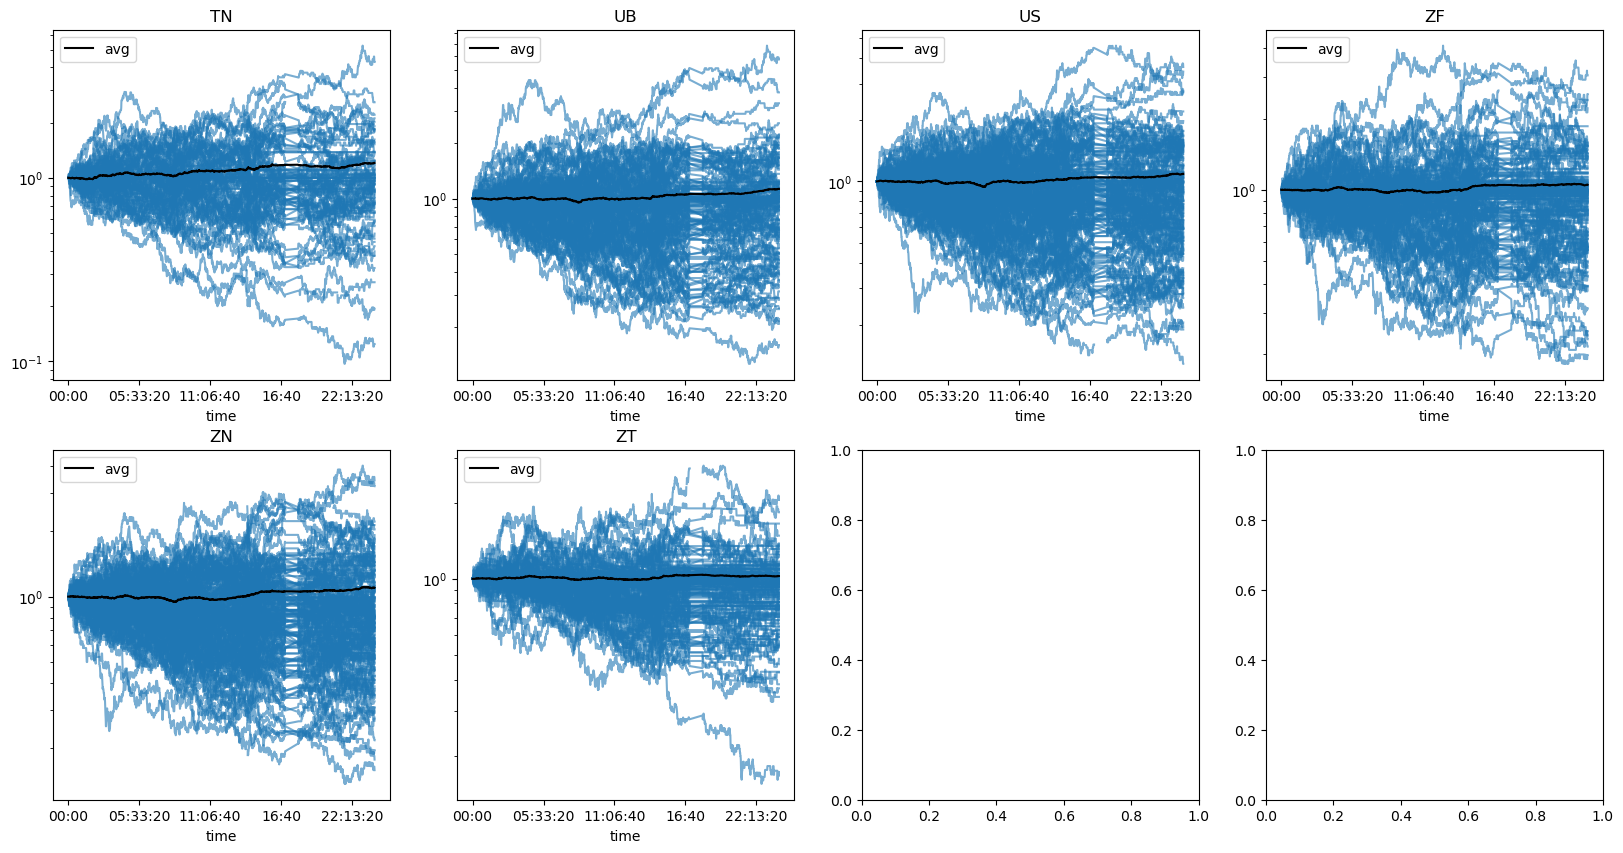

In [6]:
tickers   = df_vol_rtn.ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize=(20, 10))

for ticker, ax in zip(tickers, axes.flatten()):

    df_tmp = (df_vol_rtn
        .loc[lambda x: x.ticker == ticker]
        .pivot(index = "time", columns = "meeting_id", values = "vol_rtn")
        .fillna(0)
        .apply(lambda x: np.where(np.abs(x) > 0.1, np.nan, x)))

    df_avg = df_tmp.mean(axis = 1).to_frame(name = "avg")

    (df_tmp
        .apply(lambda x: np.cumprod(1 + x))
        .plot(
            ax     = ax,
            color  = "tab:blue",
            legend = False, 
            alpha   = 0.6))

    (df_avg
        .apply(lambda x: np.cumprod(1 + x))
        .plot(
            ax    = ax,
            logy  = True,
            color = "black",
            title = ticker))

In [7]:
df_avg_rtn = (df_vol_rtn
    .assign(vol_rtn = lambda x: np.where(np.abs(x.vol_rtn) > 0.1, np.nan, x.vol_rtn))
    .drop(columns = ["meeting_id"])
    .groupby(["ticker", "time"])
    .agg("mean")
    .reset_index())

$\downarrow$ need to lag bar for close

<Axes: title={'center': 'Cuml. Ret. Log-Scaled of Treasury Futures Around FOMC Announcement\nVolatility Targeted'}, xlabel='time'>

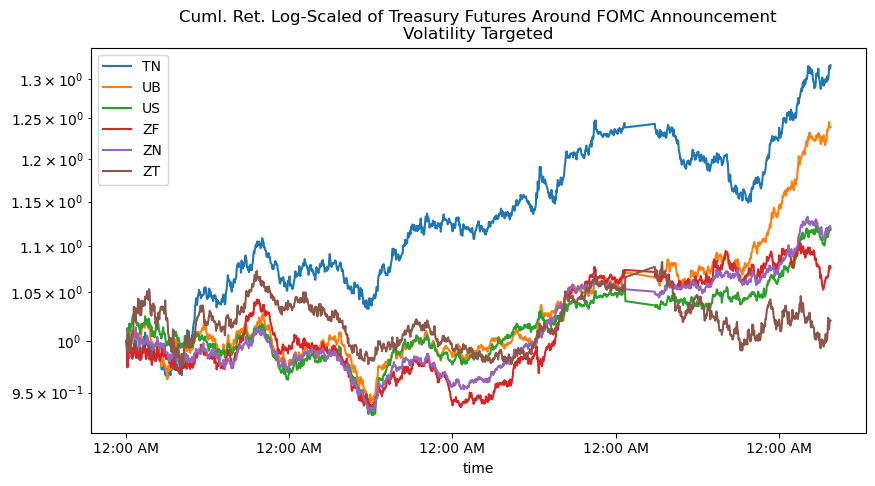

In [8]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5))

display(df_avg_rtn
    .rename(columns = {"ticker": ""})
    .pivot(index = "time", columns = "", values = "vol_rtn")
    .fillna(0)
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        logy  = True,
        ax    = ax,
        title = "Cuml. Ret. Log-Scaled of Treasury Futures Around FOMC Announcement\nVolatility Targeted"))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%I:%M %p"))
plt.show()